In [ ]:
!pip install --quiet pennylane pennylane-qiskit torchvision torch torchvision torchaudio
!pip install pennylane-qchem
!pip install pennylane-lightning



import os, time, random
from collections import Counter
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# PennyLane for QNN
import pennylane as qml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---------------- USER CONFIG ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_ROOT = "/content/drive/MyDrive/BreastMNIST_2000/BreastMNIST_2000"

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

RESNET_EPOCHS = 15
HYBRID_EPOCHS = 25
LEARNING_RATE = 1e-4

N_QUBITS = 4
N_Q_LAYERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
# ------------------------------------------------

# ---------------------------------------------------------

Device: cuda


In [ ]:
# ---------------------- TRANSFORMS -----------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # ensure single-channel
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# ---------------------- LOAD DATA ------------------------
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")

dataset_full = datasets.ImageFolder(DATA_ROOT, transform=transform)
classes = dataset_full.classes
print("Classes:", classes, "Total images:", len(dataset_full))

# Stratified split 80/10/10
targets = np.array([s[1] for s in dataset_full.samples])
idx = np.arange(len(targets))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=targets[test_idx], random_state=SEED)
print("Split sizes -> train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))

train_dataset = Subset(dataset_full, train_idx)
val_dataset = Subset(dataset_full, val_idx)
test_dataset = Subset(dataset_full, test_idx)

# Weighted sampler to address imbalance
train_labels = np.array([targets[i] for i in train_idx])
class_counts = np.bincount(train_labels)
print("Train class counts:", dict(enumerate(class_counts)))
class_weights = {i: 1.0 / class_counts[i] if class_counts[i] > 0 else 0.0 for i in range(len(class_counts))}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Classes: ['malignant', 'normal'] Total images: 2000
Split sizes -> train: 1600 val: 200 test: 200
Train class counts: {0: np.int64(1170), 1: np.int64(430)}


In [ ]:
# -------------------- UTILITIES --------------------------
def plot_confusion(y_true, y_pred, labels=classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.show()

In [ ]:
# ---------------- Perceptron Baseline (optional) -----------
def run_perceptron_baseline():
    # load all images into memory (careful if huge)
    loader_all = DataLoader(dataset_full, batch_size=len(dataset_full), shuffle=False)
    imgs, labs = next(iter(loader_all))
    imgs = imgs.numpy()  # shape (N,1,H,W)
    N = imgs.shape[0]
    X = imgs.reshape(N, -1)
    y = labs.numpy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    from sklearn.linear_model import Perceptron as SKPerceptron
    perc = SKPerceptron(max_iter=2000, tol=1e-3, random_state=SEED)
    perc.fit(X_train, y_train)
    y_pred = perc.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Perceptron accuracy: {acc:.2f}%")
    print(classification_report(y_test, y_pred, target_names=classes))
    plot_confusion(y_test, y_pred, labels=classes, title="Perceptron Confusion Matrix")

In [ ]:

# ---------------- ResNet baseline (classical) ----------------
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        # adapt first conv to single channel if dataset is grayscale
        if self.backbone.conv1.in_channels != 1:
            w = self.backbone.conv1.weight.data
            new_w = w.mean(dim=1, keepdim=True)   # average channel weights to make single-channel conv
            self.backbone.conv1 = nn.Conv2d(1, w.shape[0], kernel_size=7, stride=2, padding=3, bias=False)
            self.backbone.conv1.weight.data = new_w
        # replace final fc
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    def forward(self, x):
        return self.backbone(x)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    start = time.time()
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += data.size(0)
    epoch_time = time.time() - start
    return running_loss/total, 100*correct/total, epoch_time

def evaluate_model(model, loader, device):
    model.eval().to(device)
    y_true, y_pred = [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            loss = criterion(out, target)
            total_loss += loss.item() * data.size(0)
            preds = out.argmax(dim=1)
            y_true.extend(target.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred) * 100.0
    return avg_loss, acc, np.array(y_true), np.array(y_pred)

In [ ]:
# ---------------- PennyLane QNN auxiliary block ----------------
n_qubits = N_QUBITS
n_layers = N_Q_LAYERS
dev = qml.device("default.qubit", wires=n_qubits)   # CPU quantum simulator

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    # inputs: length n_qubits (torch tensor), weights: (n_layers,n_qubits)
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
    qml.templates.BasicEntanglerLayers(weights, wires=range(n_qubits))
    # return expectation values (one per qubit)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class QNNAux(nn.Module):
    """ Small QNN auxiliary block — returns n_qubits outputs for each sample """
    def __init__(self, n_qubits=n_qubits, n_layers=n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        # trainable weights for the QNN
        # shape (n_layers, n_qubits)
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, dtype=torch.float32))

    def forward(self, x):
        # x shape: (batch, features). We'll use first n_qubits features per sample (projected to [-pi,pi])
        out_list = []
        device = x.device
        for sample in x:
            inp = sample[:self.n_qubits].to(torch.float32)
            # scale to small range [-pi, pi]
            inp = torch.tanh(inp) * np.pi
            qout = qnode(inp, self.weights)   # returns a sequence or torch tensor
            # Ensure torch.tensor and move to same device
            qout = torch.as_tensor(qout, dtype=torch.float32).to(device)
            out_list.append(qout)
        return torch.stack(out_list)  # (batch, n_qubits)


In [ ]:
# ---------------- Hybrid model: ResNet features -> projection -> QNNAux -> classifier ----------------
class HybridResNetQNN(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, n_qubits=n_qubits, freeze_backbone=False):
        super().__init__()
        # use ResNet feature extractor (without final FC)
        res = models.resnet18(pretrained=pretrained)
        if res.conv1.in_channels != 1:
            w = res.conv1.weight.data
            new_w = w.mean(dim=1, keepdim=True)
            res.conv1 = nn.Conv2d(1, w.shape[0], kernel_size=7, stride=2, padding=3, bias=False)
            res.conv1.weight.data = new_w
        # take feature extractor (all layers except final fc)
        self.backbone = nn.Sequential(*list(res.children())[:-1])  # outputs (batch,512,1,1)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # flatten feature dim
        self.feature_dim = 512  # resnet18 final conv outputs 512 features after avgpool
        # classical projector: reduce 512 -> latent (64) -> provide inputs to QNN
        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_qubits),   # produce exactly n_qubits values (will be fed to qnn)
        )

        self.qnn_aux = QNNAux(n_qubits=n_qubits, n_layers=n_layers)

        # classical post-QNN classifier: takes qnn outputs (n_qubits) and optionally backbone features as well
        # We'll concatenate QNN outputs + a small classical summary (e.g. from projector) for final decision:
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits + 32, 64),   # 32-dense summary from backbone
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        # small summary head from backbone features
        self.summary_head = nn.Sequential(
            nn.Linear(self.feature_dim, 32),
            nn.ReLU()
        )

    def forward(self, x):
        # backbone -> avgpool output (batch,512,1,1) -> flatten
        feat = self.backbone(x)  # shape (b,512,1,1)
        feat = feat.view(feat.size(0), -1)  # (b,512)
        proj = self.projector(feat)         # (b, n_qubits)  classical projection
        q_out = self.qnn_aux(proj)          # (b, n_qubits)
        summary = self.summary_head(feat)   # (b, 32)
        combined = torch.cat([q_out, summary], dim=1)   # (b, n_qubits + 32)
        out = self.classifier(combined)
        return out

In [ ]:
# ---------------- Train/Eval wrappers ----------------
def fit_model(model, train_loader, val_loader, epochs, lr, device, class_counts=None, name="model"):
    model = model.to(device)
    if class_counts is None:
        weight = torch.tensor([1.0, 1.0], dtype=torch.float32).to(device)
    else:
        inv = [1.0 / c if c>0 else 0.0 for c in class_counts]
        weight = torch.tensor(inv, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_val_acc = -1.0
    best_state = None
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc, _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, yv_true, yv_pred = evaluate_model(model, val_loader, device)
        dt = time.time() - t0
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}% | Time: {dt:.1f}s")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            torch.save(best_state, f"{name}_best.pth")
            print("  Saved best model.")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


=== ResNet baseline training ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 63.0MB/s]


Epoch 1/15 | Train Loss: 0.3340 Train Acc: 78.75% | Val Loss: 0.6172 Val Acc: 70.50% | Time: 160.8s
  Saved best model.
Epoch 2/15 | Train Loss: 0.1504 Train Acc: 92.44% | Val Loss: 0.5276 Val Acc: 82.00% | Time: 62.4s
  Saved best model.
Epoch 3/15 | Train Loss: 0.0850 Train Acc: 96.44% | Val Loss: 0.4624 Val Acc: 84.00% | Time: 36.2s
  Saved best model.
Epoch 4/15 | Train Loss: 0.0428 Train Acc: 98.44% | Val Loss: 0.5406 Val Acc: 83.50% | Time: 20.6s
Epoch 5/15 | Train Loss: 0.0218 Train Acc: 99.06% | Val Loss: 0.4926 Val Acc: 86.00% | Time: 15.6s
  Saved best model.
Epoch 6/15 | Train Loss: 0.0258 Train Acc: 99.19% | Val Loss: 0.4988 Val Acc: 88.00% | Time: 10.8s
  Saved best model.
Epoch 7/15 | Train Loss: 0.0187 Train Acc: 99.31% | Val Loss: 0.5993 Val Acc: 85.50% | Time: 7.9s
Epoch 8/15 | Train Loss: 0.0199 Train Acc: 99.19% | Val Loss: 0.6114 Val Acc: 85.50% | Time: 7.6s
Epoch 9/15 | Train Loss: 0.0294 Train Acc: 98.75% | Val Loss: 0.5650 Val Acc: 83.00% | Time: 6.0s
Epoch 10/15

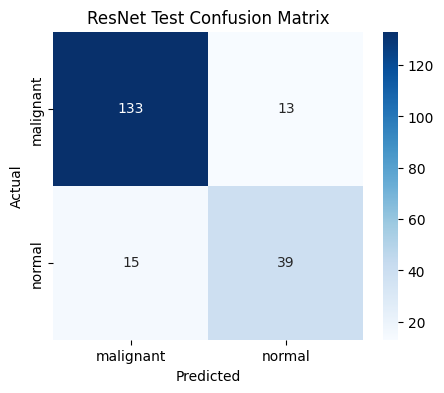

ResNet avg inference per batch (bs=32): 0.0118s -> per image 0.000369s


In [ ]:

# ---------------- Run experiments ----------------
print("\n=== ResNet baseline training ===")
resnet = ResNetClassifier(num_classes=len(dataset_full.classes), pretrained=True)
resnet = fit_model(resnet, train_loader, val_loader, RESNET_EPOCHS, LEARNING_RATE, DEVICE, class_counts=class_counts, name="resnet")

res_val_loss, res_val_acc, y_res_true, y_res_pred = evaluate_model(resnet, test_loader, DEVICE)
print(f"\nResNet Test Accuracy: {res_val_acc:.2f}%")
print(classification_report(y_res_true, y_res_pred, target_names=dataset_full.classes))
plot_confusion(y_res_true, y_res_pred, labels=dataset_full.classes, title="ResNet Test Confusion Matrix")

# measure inference speed ResNet
resnet.to(DEVICE).eval()
batch_times = []
with torch.no_grad():
    for i, (data, _) in enumerate(test_loader):
        if i >= 50: break
        s = time.time()
        _ = resnet(data.to(DEVICE))
        batch_times.append(time.time() - s)
if len(batch_times) > 0:
    print(f"ResNet avg inference per batch (bs={BATCH_SIZE}): {np.mean(batch_times):.4f}s -> per image {np.mean(batch_times)/BATCH_SIZE:.6f}s")


=== Hybrid ResNet->QNN training ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training Hybrid on device: cpu


/tmp/ipython-input-2756835462.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  qout = torch.as_tensor(qout, dtype=torch.float32).to(device)


Epoch 1/25 | Train Loss: 0.4732 Train Acc: 58.62% | Val Loss: 0.6151 Val Acc: 68.50% | Time: 142.6s
  Saved best model.
Epoch 2/25 | Train Loss: 0.2396 Train Acc: 89.56% | Val Loss: 0.4233 Val Acc: 83.00% | Time: 142.0s
  Saved best model.
Epoch 3/25 | Train Loss: 0.1398 Train Acc: 94.62% | Val Loss: 0.5183 Val Acc: 82.50% | Time: 141.1s
Epoch 4/25 | Train Loss: 0.0931 Train Acc: 96.88% | Val Loss: 0.4319 Val Acc: 84.50% | Time: 141.5s
  Saved best model.
Epoch 5/25 | Train Loss: 0.0631 Train Acc: 97.06% | Val Loss: 0.4806 Val Acc: 83.00% | Time: 141.9s
Epoch 6/25 | Train Loss: 0.0403 Train Acc: 98.19% | Val Loss: 0.5681 Val Acc: 84.00% | Time: 141.4s
Epoch 7/25 | Train Loss: 0.0353 Train Acc: 98.44% | Val Loss: 0.6358 Val Acc: 84.50% | Time: 141.4s
Epoch 8/25 | Train Loss: 0.0438 Train Acc: 98.19% | Val Loss: 0.5236 Val Acc: 86.50% | Time: 142.8s
  Saved best model.
Epoch 9/25 | Train Loss: 0.0301 Train Acc: 98.69% | Val Loss: 0.5058 Val Acc: 85.50% | Time: 141.0s
Epoch 10/25 | Train 

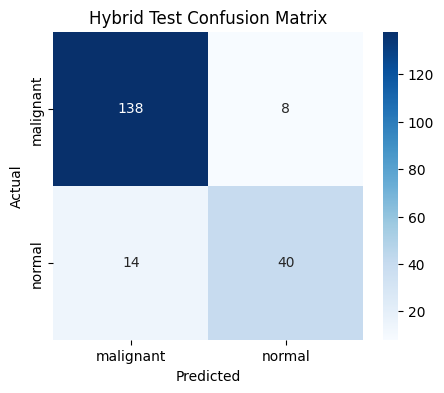

Hybrid avg inference per batch (bs=32) on cpu: 0.8339s -> per image 0.026059s


In [ ]:
# ---------------- Hybrid model training (ResNet features + QNNAux) ----------------
print("\n=== Hybrid ResNet->QNN training ===")
hybrid = HybridResNetQNN(num_classes=len(dataset_full.classes), pretrained=True, n_qubits=n_qubits)
# NOTE: PennyLane default.qubit executes on CPU; place hybrid model on CPU for training to match QNN behaviour (or keep on CPU)
# If you have a GPU and PennyLane CPU qnode, putting model on GPU will cause device mismatches for qnode outputs.
# We'll set device to CPU for hybrid training (safe).
HYBRID_DEVICE = torch.device("cpu")
print("Training Hybrid on device:", HYBRID_DEVICE)

hybrid = fit_model(hybrid, train_loader, val_loader, HYBRID_EPOCHS, LEARNING_RATE, HYBRID_DEVICE, class_counts=class_counts, name="hybrid")

hy_loss, hy_acc, y_h_true, y_h_pred = evaluate_model(hybrid, test_loader, HYBRID_DEVICE)
print(f"\nHybrid Test Accuracy: {hy_acc:.2f}%")
print(classification_report(y_h_true, y_h_pred, target_names=dataset_full.classes))
plot_confusion(y_h_true, y_h_pred, labels=dataset_full.classes, title="Hybrid Test Confusion Matrix")

# measure hybrid inference speed (on HYBRID_DEVICE)
hybrid.eval()
batch_times = []
with torch.no_grad():
    for i, (data, _) in enumerate(test_loader):
        if i >= 50: break
        s = time.time()
        # ensure running on HYBRID_DEVICE
        _ = hybrid(data.to(HYBRID_DEVICE))
        batch_times.append(time.time() - s)
if len(batch_times) > 0:
    print(f"Hybrid avg inference per batch (bs={BATCH_SIZE}) on {HYBRID_DEVICE}: {np.mean(batch_times):.4f}s -> per image {np.mean(batch_times)/BATCH_SIZE:.6f}s")

In [ ]:
print("--- Model Performance Comparison ---")
print(f"Hybrid ResNet-QNN Test Accuracy: {hy_acc:.2f}%")
print(f"ResNet Baseline Test Accuracy: {res_val_acc:.2f}%")

if 'perc' in globals():
    # If you ran the perceptron baseline
    perc_acc = accuracy_score(y_test, perc.predict(X_test)) * 100
    print(f"Perceptron Baseline Test Accuracy: {perc_acc:.2f}%")

--- Model Performance Comparison ---
Hybrid ResNet-QNN Test Accuracy: 89.00%
ResNet Baseline Test Accuracy: 86.00%
